In [5]:
import pandas as pd
import seaborn as sns

In [3]:
df = pd.read_csv('diabetic_data.csv')
df

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO


In [4]:
##Perform descriptive statistical analysis for numberical features:

df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


<Axes: xlabel='race', ylabel='Count'>

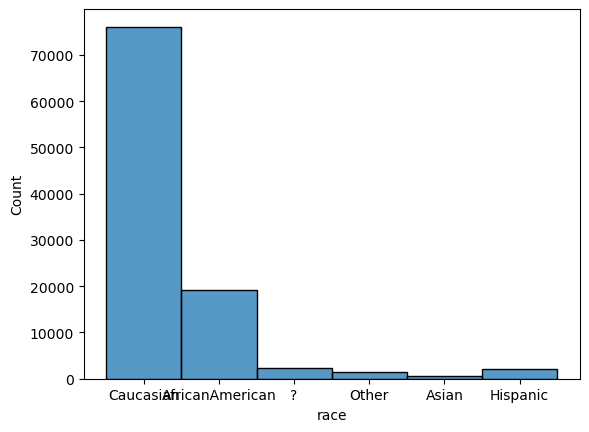

In [6]:
##Visualize the distribution of categorical features race and gender

sns.histplot(data=df, x="race")

<Axes: xlabel='gender', ylabel='Count'>

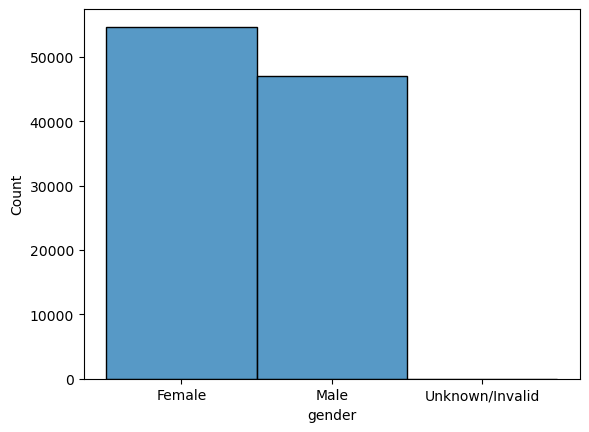

In [7]:
sns.histplot(data=df, x="gender")

<Axes: xlabel='age', ylabel='count'>

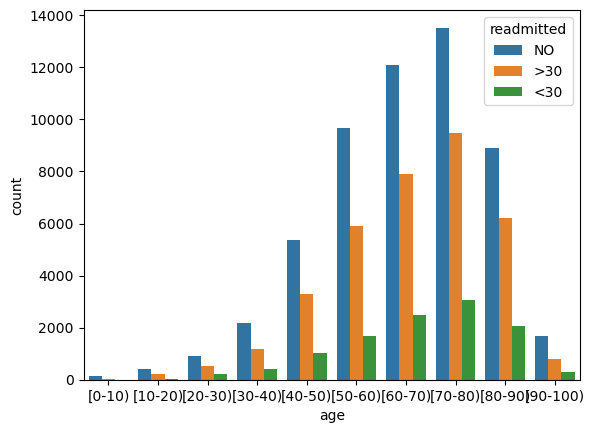

In [9]:
##Explore the relationship between readmission status and age

sns.countplot(data=df, x="age", hue="readmitted")

In [19]:
##Investigate correlations between umerical features

corr_matrix = df[['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']].copy()
corr_matrix.corr()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
time_in_hospital,1.000000,0.318450,0.191472,0.466135,-0.008916,-0.009681,0.073623,0.220186
num_lab_procedures,0.318450,1.000000,0.058066,0.268161,-0.007602,-0.002279,0.039231,0.152773
num_procedures,0.191472,0.058066,1.000000,0.385767,-0.024819,-0.038179,-0.066236,0.073734
num_medications,0.466135,0.268161,0.385767,1.000000,0.045197,0.013180,0.064194,0.261526
number_outpatient,-0.008916,-0.007602,-0.024819,0.045197,1.000000,0.091459,0.107338,0.094152
number_emergency,-0.009681,-0.002279,-0.038179,0.013180,0.091459,1.000000,0.266559,0.055539
number_inpatient,0.073623,0.039231,-0.066236,0.064194,0.107338,0.266559,1.000000,0.104710
number_diagnoses,0.220186,0.152773,0.073734,0.261526,0.094152,0.055539,0.104710,1.000000


<Axes: xlabel='change', ylabel='num_medications'>

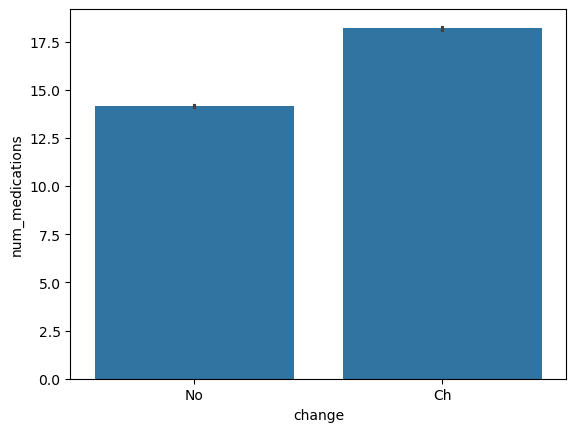

In [28]:
##Analyze the distribution of medication changes and total medications taken.

sns.barplot(data=df, x="change", y="num_medications")

<Axes: xlabel='diag_1', ylabel='Count'>

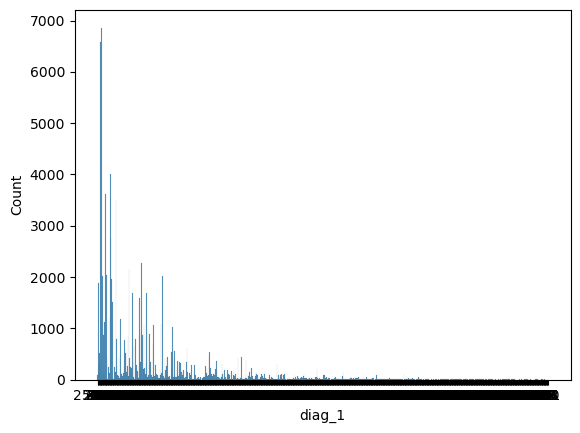

In [29]:
##Examine the distribution of diagnoses categories

sns.histplot(data=df, x="diag_1")

<Axes: xlabel='admission_type_id', ylabel='Count'>

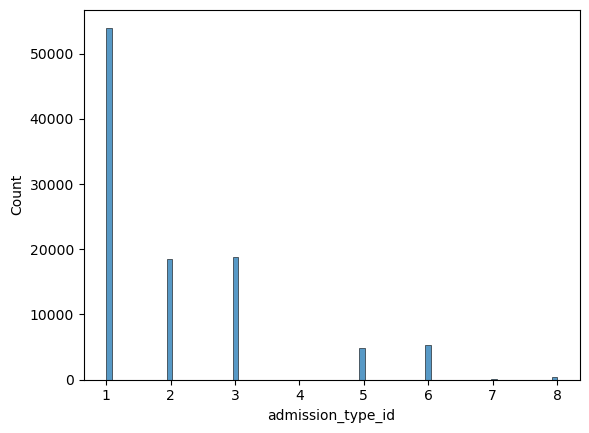

In [32]:
##Explore the distribution of patients across admission types, sources, and discharge dispositions

sns.histplot(data=df, x="admission_type_id")

<Axes: xlabel='admission_source_id', ylabel='Count'>

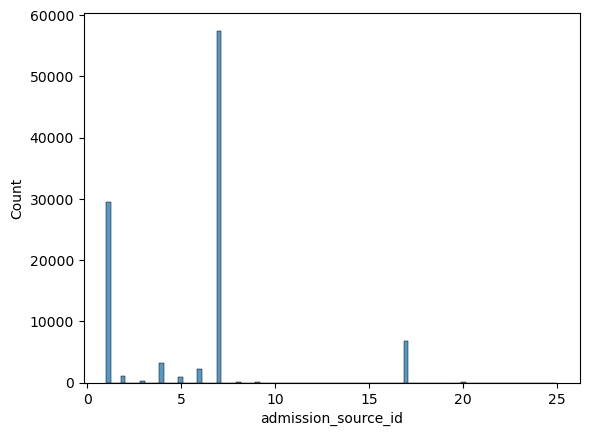

In [33]:
sns.histplot(data=df, x="admission_source_id")

<Axes: xlabel='discharge_disposition_id', ylabel='Count'>

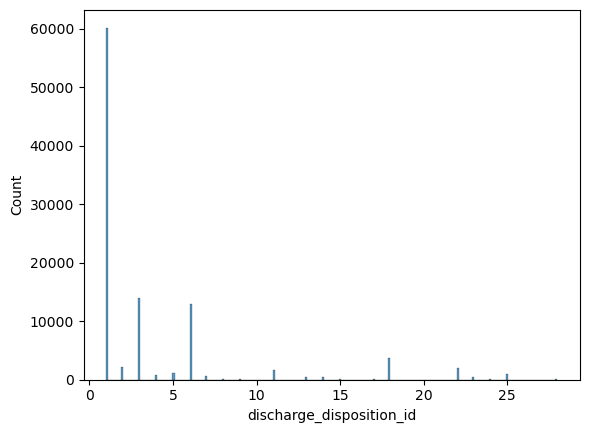

In [34]:
sns.histplot(data=df, x="discharge_disposition_id")

In [35]:
##Identify and visualize any outliets in the dataset, especially in numerical features

corr_matrix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype
---  ------              --------------   -----
 0   time_in_hospital    101766 non-null  int64
 1   num_lab_procedures  101766 non-null  int64
 2   num_procedures      101766 non-null  int64
 3   num_medications     101766 non-null  int64
 4   number_outpatient   101766 non-null  int64
 5   number_emergency    101766 non-null  int64
 6   number_inpatient    101766 non-null  int64
 7   number_diagnoses    101766 non-null  int64
dtypes: int64(8)
memory usage: 6.2 MB


<Axes: xlabel='time_in_hospital'>

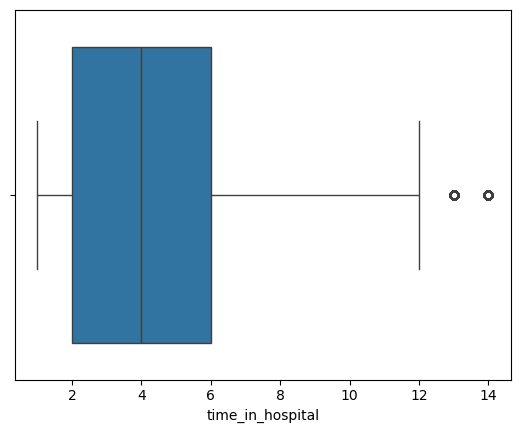

In [38]:
sns.boxplot(x=df['time_in_hospital'])

<Axes: xlabel='num_lab_procedures'>

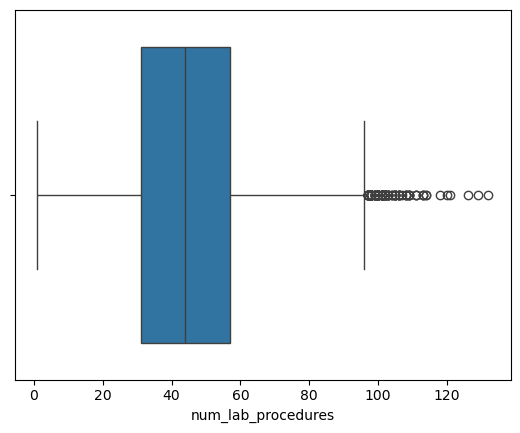

In [37]:
sns.boxplot(x=df['num_lab_procedures'])

<Axes: xlabel='num_medications'>

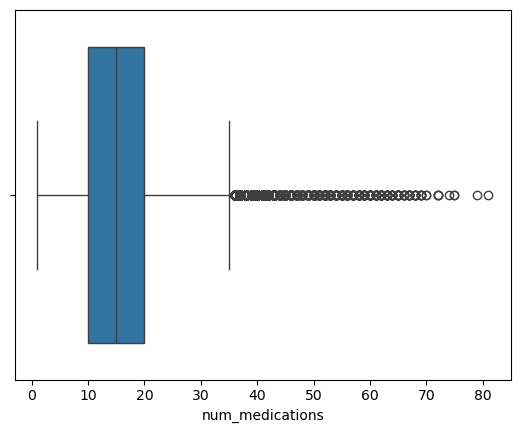

In [39]:
sns.boxplot(x=df['num_medications'])

<Axes: xlabel='number_outpatient'>

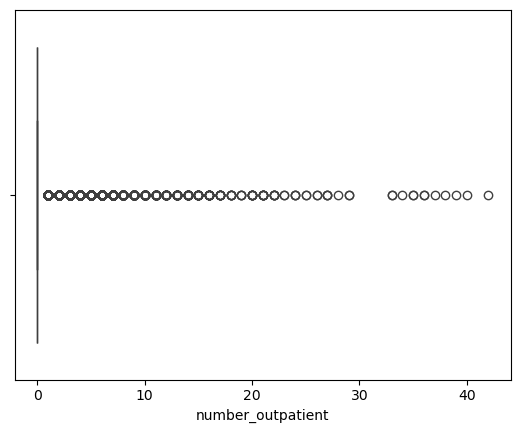

In [40]:
sns.boxplot(x=df['number_outpatient'])

<Axes: xlabel='number_emergency'>

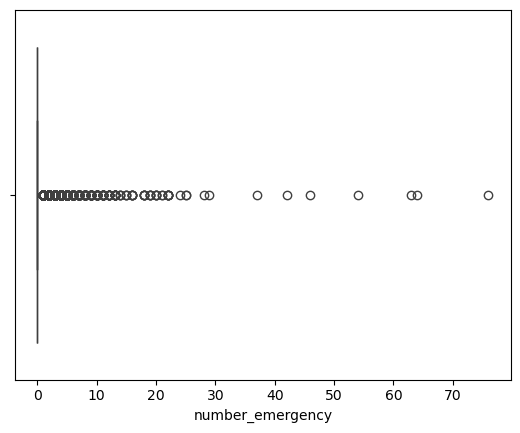

In [42]:
sns.boxplot(x=df['number_emergency'])

<Axes: xlabel='number_inpatient'>

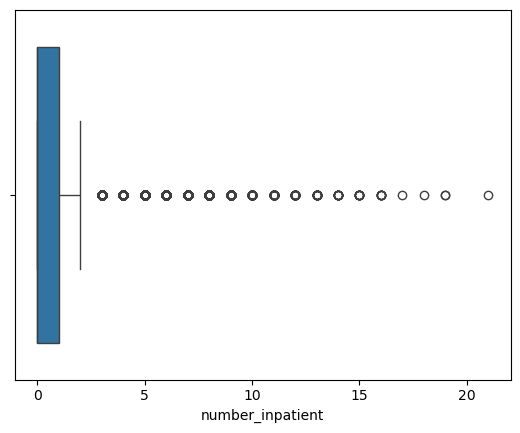

In [43]:
sns.boxplot(x=df['number_inpatient'])

<Axes: xlabel='number_diagnoses'>

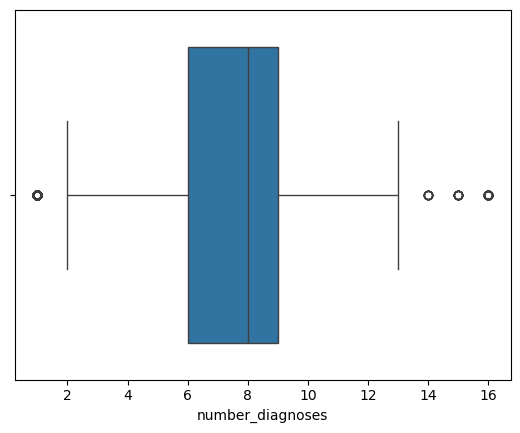

In [44]:
sns.boxplot(x=df['number_diagnoses'])